In [ ]:
需要将PaddleHub和PaddlePaddle统一升级到2.0版本
!pip install paddlehub==2.0.0 -i https://pypi.tuna.tsinghua.edu.cn/simple
!pip install paddlepaddle==2.0.0 -i https://pypi.tuna.tsinghua.edu.cn/simple
#该Module依赖于第三方库shapely、pyclipper，使用该Module之前，请先安装shapely、pyclipper
!pip install shapely -i https://pypi.tuna.tsinghua.edu.cn/simple
!pip install pyclipper -i https://pypi.tuna.tsinghua.edu.cn/simple

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 待预测图片
test_img_path = ["./advertisement.jpg", "./pics.jpg", "./identity_card.jpg", "./express.jpg", "./railway_ticket.jpg"]

# 展示其中广告信息图片
img1 = mpimg.imread(test_img_path[0])
plt.figure(figsize=(10,10))
plt.imshow(img1)
plt.axis('off')
plt.show()

In [ ]:
!cat test.txt

In [ ]:
with open('test.txt', 'r') as f:
    test_img_path=[]
    for line in f:
        test_img_path.append(line.strip())@#
print(test_img_path)

###二、加载预训练模型
PaddleHub提供了以下文字识别模型：

移动端的超轻量模型：仅有8.1M，chinese_ocr_db_crnn_mobile。

服务器端的精度更高模型：识别精度更高，chinese_ocr_db_crnn_server。

识别文字算法均采用CRNN（Convolutional Recurrent Neural Network）即卷积递归神经网络。其是DCNN和RNN的组合，专门用于识别图像中的序列式对象。与CTC loss配合使用，进行文字识别，可以直接从文本词级或行级的标注中学习，不需要详细的字符级的标注。该Module支持直接预测。 移动端与服务器端主要在于骨干网络的差异性，移动端采用MobileNetV3，服务器端采用ResNet50_vd。

In [ ]:
import paddlehub as hub

# 加载移动端预训练模型
ocr = hub.Module(name="chinese_ocr_db_crnn_mobile")
# 服务端可以加载大模型，效果更好
# ocr = hub.Module(name="chinese_ocr_db_crnn_server")

### 三、预测

In [ ]:
import cv2

# 读取测试文件夹test.txt中的照片路径
np_images =[cv2.imread(image_path) for image_path in test_img_path]

results = ocr.recognize_text(
                    images=np_images,         # 图片数据，ndarray.shape 为 [H, W, C]，BGR格式；
                    use_gpu=False,            # 是否使用 GPU；若使用GPU，请先设置CUDA_VISIBLE_DEVICES环境变量
                    output_dir='ocr_result',  # 图片的保存路径，默认设为 ocr_result；
                    visualization=True,       # 是否将识别结果保存为图片文件；
                    box_thresh=0.5,           # 检测文本框置信度的阈值；
                    text_thresh=0.5)          # 识别中文文本置信度的阈值；

for result in results:
    data = result['data']
    save_path = result['save_path']
    for infomation in data:
        print('text: ', infomation['text'], '\nconfidence: ', infomation['confidence'], '\ntext_box_position: ', infomation['text_box_position'])

In [ ]:
四、效果展示
PaddleHub对于支持一键预测的module，可以调用module的相应预测API，完成预测功能。在完成第三部分的一键OCR预测之后，由于我们设置了visualization=True，所以我们会自动将识别结果保存为图片文件，并默认保存在ocr_result文件夹中。刷新即可获取到新生成的ocr_result文件夹。

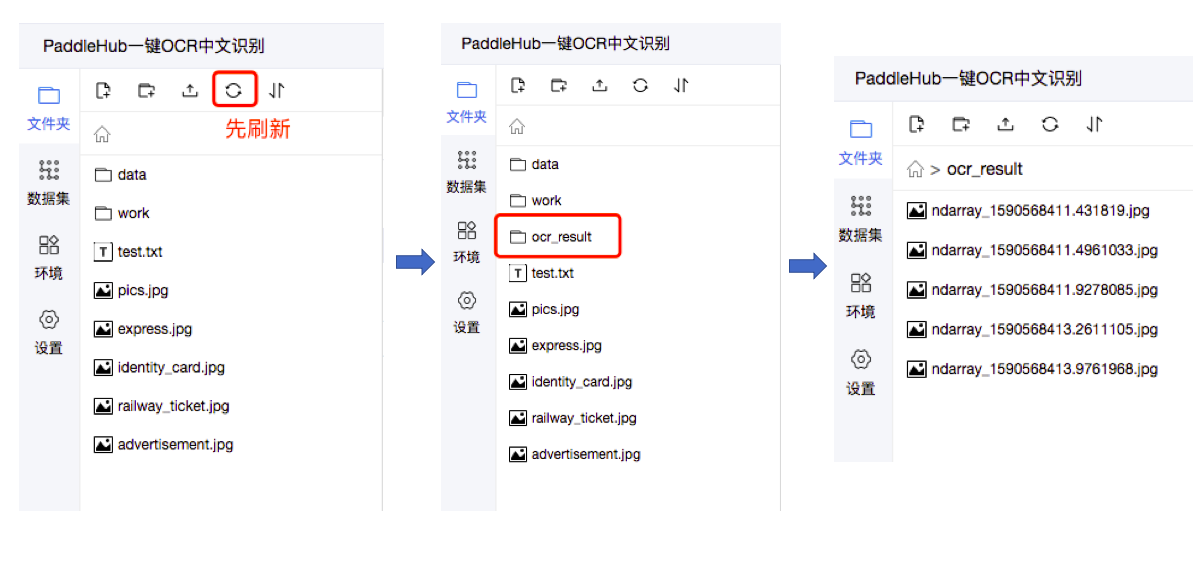